In [1]:
# 0. Preparación de ambientes necesarios

# Importar librerias
import pandas as pd
import xarray as xr
import numpy as np

import os
import errno
import geopandas as gpd
import seaborn as sns


import shapely
from shapely.geometry import shape, Polygon, Point, MultiPoint, box, LineString

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import cartopy
from cartopy import config
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader as sf
import cartopy.feature as cfeature


from mpl_toolkits.axes_grid1 import make_axes_locatable


from cmcrameri import cm

In [ ]:
# 1. DATA 

data_rocloud = '../data/raw/rocloud.csv'

df_rocloud = pd.read_csv(
        data_rocloud,  
        index_col=0
    )
display(df_rocloud)

,dd,mm,yy,hh,lat,lon,MWS,CPSL,RNE,RNO,RSO,RSE,Rp,A,D,S,CT
0,7,6,2000,18,21.0,-93.0,46.25,1008,685.02,553.70,892.42,868.72,749.96,0.38,0.41,0.13,AL012000
1,8,6,2000,0,20.9,-92.8,46.25,1009,721.32,618.31,956.51,726.56,755.68,0.35,0.60,0.16,AL012000
2,8,6,2000,6,20.7,-93.1,46.25,1010,578.83,384.43,752.94,919.22,658.86,0.58,0.68,0.12,AL012000
3,8,6,2000,12,20.8,-93.5,46.25,1010,664.24,410.25,714.98,877.39,666.72,0.53,0.46,0.09,AL012000
4,5,6,2001,12,27.5,-95.0,74.00,1007,849.75,235.63,360.69,667.28,528.34,0.72,0.43,0.32,AL012001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8421,6,11,2023,12,10.6,-115.0,46.44,1006,647.31,0.00,668.02,622.11,645.81,1.00,0.55,0.29,EP192023
8422,6,11,2023,18,10.7,-115.3,46.44,1007,606.41,557.72,642.99,631.80,609.73,0.13,0.49,0.23,EP192023
8423,7,11,2023,0,11.0,-116.2,46.44,1007,566.80,425.28,729.26,542.57,565.98,0.42,0.64,0.20,EP192023
8424,7,11,2023,6,12.1,-117.0,46.44,1007,662.10,0.00,685.11,563.32,636.84,1.00,0.69,0.12,EP192023


In [18]:
df_rocloud['basin'] = df_rocloud['CT'].apply(lambda x: 'NA' if x[0:2] == 'AL' else 'EP')
td = df_rocloud[df_rocloud.MWS.le(63)].copy().reset_index(drop=True)
ts = df_rocloud[df_rocloud.MWS.gt(63) & df_rocloud.MWS.le(119)].copy().reset_index(drop=True)
minor = df_rocloud[df_rocloud.MWS.gt(119) & df_rocloud.MWS.le(178)].copy().reset_index(drop=True)
major = df_rocloud[df_rocloud.MWS.gt(178)].copy().reset_index(drop=True)

In [21]:
def plot_boxpanel(
    ax,
    df,
    title,
    label,
    *,
    value_vars,
    category_name,
    id_var="cuenca",
    rename_categories=None,
    ylim=None,
    palette=None,
):
    """
    Genera un boxplot comparativo por cuenca para un conjunto de variables.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Eje donde se dibujará el gráfico.

    df : pandas.DataFrame
        DataFrame de entrada. Debe contener la columna `id_var` y las columnas
        especificadas en `value_vars`.

    title : str
        Título descriptivo del panel.

    label : str
        Letra o identificador del panel, por ejemplo 'A', 'B', 'C'.

    value_vars : list[str]
        Columnas numéricas que serán transformadas a formato largo.

    category_name : str
        Nombre de la variable categórica resultante después de `melt`.
        Por ejemplo: 'radio' o 'variable'.

    id_var : str, default 'cuenca'
        Columna usada como identificador del grupo principal.

    rename_categories : dict or None, default None
        Diccionario opcional para renombrar categorías.
        Ejemplo: {'RNO': 'RNW', 'RSO': 'RSW'}.

    ylim : tuple or None, default None
        Límites del eje Y. Ejemplo: (0, 2500).

    palette : list or None, default None
        Paleta de colores para las categorías de `id_var`.
    """

    # Número de eventos o registros
    N = df.shape[0]

    # Título del panel
    ax.set_title(rf'$\mathbf{{{label}.}}$ {title}', fontsize=18)

    # Texto con tamaño muestral
    ax.text(
        0.5,
        0.95,
        f'N = {N}',
        ha='center',
        va='bottom',
        transform=ax.transAxes,
        fontsize=16,
    )

    # Transformación a formato largo
    melted = df.melt(
        id_vars=[id_var],
        value_vars=value_vars,
        var_name=category_name,
        value_name='valor',
    )

    # Renombrar categorías si aplica
    if rename_categories is not None:
        melted[category_name] = melted[category_name].replace(rename_categories)

    # Paleta por defecto
    if palette is None:
        palette = [cm.bam(10), cm.bam_r(0)]

    # Boxplot
    sns.boxplot(
        data=melted,
        x=category_name,
        y='valor',
        hue=id_var,
        fill=False,
        ax=ax,
        legend=False,
        palette=palette,
        flierprops=dict(marker='x', markersize=3),
        gap=0.2,
        fliersize=0.5,
        capprops=dict(color='w'),
        showmeans=True,
        meanprops={
            "marker": "o",
            "markeredgewidth": 2,
            "markerfacecolor": "w",
            "markeredgecolor": "k",
            "markersize": 6,
        },
    )

    # Estética general
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel(' ')
    ax.set_ylabel(' ')

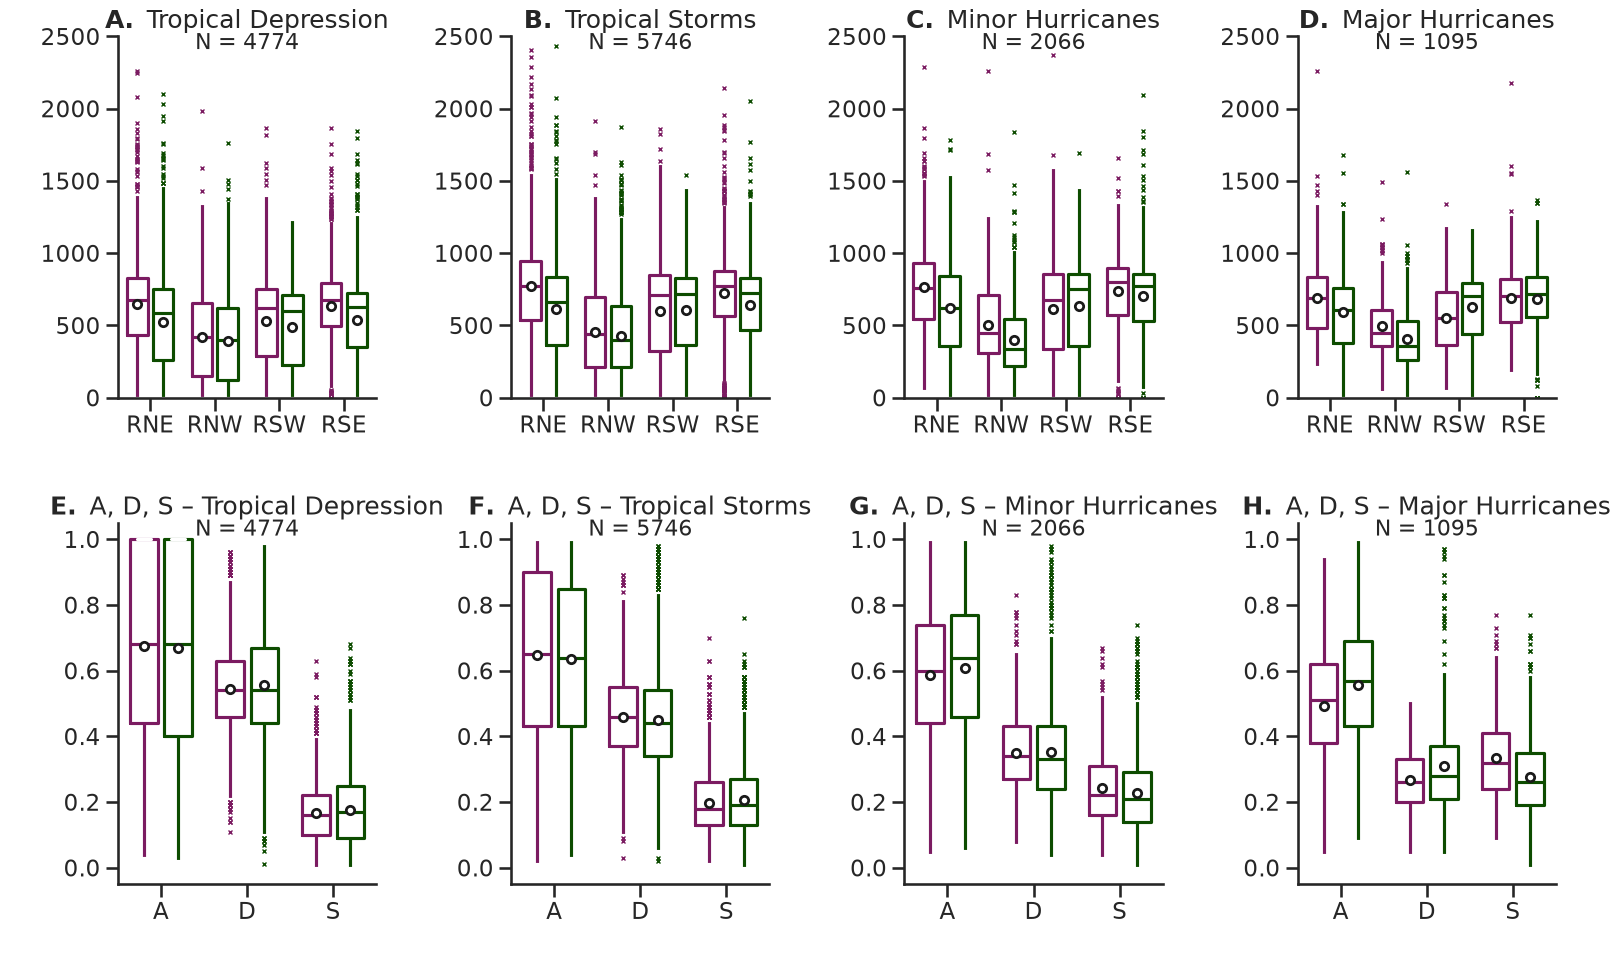

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from cmcrameri import cm

# =========================
# Crear columna de cuenca en todos los DF
# =========================
for df_var in [td, ts, minor, major]:
    df_var['cuenca'] = df_var['CT'].apply(lambda x: 'Atlántico' if str(x).startswith('AL') else 'Pacífico')

# =========================
# Configuración general
# =========================
fig = plt.figure(figsize=(16, 10))

custom_params = {"axes.spines.right": True, "axes.spines.top": False, "axes.spines.left": False}
sns.set_theme(style='whitegrid', context="talk", rc=custom_params, color_codes=True)
sns.set_style("ticks")

# =========================
# Gridspec: 2 filas x 4 columnas
# Fila 0: radios (RNE–RSE)
# Fila 1: A, D, S
# =========================
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1], width_ratios=[1, 1, 1, 1])

# =========================
# Dataset configuration
# =========================
categories = [
    (td,    "Tropical Depression"),
    (ts,    "Tropical Storms"),
    (minor, "Minor Hurricanes"),
    (major, "Major Hurricanes"),
]

panel_labels_radios = ["A", "B", "C", "D"]
panel_labels_ads = ["E", "F", "G", "H"]

# =========================
# Row 0: RNE, RNW, RSW, RSE
# =========================
for col, ((df, title), label) in enumerate(zip(categories, panel_labels_radios)):
    ax = fig.add_subplot(gs[0, col])

    plot_boxpanel(
        ax=ax,
        df=df,
        title=title,
        label=label,
        value_vars=["RNE", "RNO", "RSO", "RSE"],
        category_name="radio",
        rename_categories={
            "RNO": "RNW",
            "RSO": "RSW",
        },
        ylim=(0, 2500),
    )

# =========================
# Row 1: A, D, S
# =========================
for col, ((df, title), label) in enumerate(zip(categories, panel_labels_ads)):
    ax = fig.add_subplot(gs[1, col])

    plot_boxpanel(
        ax=ax,
        df=df,
        title=f"A, D, S – {title}",
        label=label,
        value_vars=["A", "D", "S"],
        category_name="variable",
    )

# ----------------------------------------------------------------------------------
# Layout final
# ----------------------------------------------------------------------------------
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.tight_layout()
# fig.savefig("figure_boxplots_ADS_por_categoria.jpeg", dpi=300, bbox_inches='tight')
plt.show()
